# PubMed RCT Classification - Optimized Training Pipeline

SciBERT fine-tuning with warmup scheduler, class weights, mixed precision, gradient accumulation, and staged unfreezing.

## Setup & Installation

In [1]:
# Install required packages if needed
# !pip install torch transformers pandas numpy scikit-learn matplotlib seaborn tqdm accelerate datasets -q

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
AMP_DTYPE = (
    torch.bfloat16 if USE_AMP and torch.cuda.is_bf16_supported() else torch.float16
)
USE_TORCH_COMPILE = True

if USE_AMP:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    if hasattr(torch.backends.cuda, "enable_flash_sdp"):
        torch.backends.cuda.enable_flash_sdp(True)
        torch.backends.cuda.enable_mem_efficient_sdp(True)
        torch.backends.cuda.enable_math_sdp(True)

print(f"Using device: {device}")
if USE_AMP:
    print(f"AMP dtype: {AMP_DTYPE}")

LABEL2ID = {
    "BACKGROUND": 0,
    "OBJECTIVE": 1,
    "METHODS": 2,
    "RESULTS": 3,
    "CONCLUSIONS": 4,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = len(LABEL2ID)
MODEL_NAME = "allenai/scibert_scivocab_uncased"
MAX_LENGTH = 256
BATCH_SIZE = 96 # 64
GRADIENT_ACCUMULATION_STEPS = 1
EPOCHS = 50
FREEZE_EPOCHS = 1
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 0.001
SEED = 42
NUM_WORKERS = 12
PREFETCH_FACTOR = 6
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda
AMP dtype: torch.bfloat16


## Data Loading & Preprocessing

In [3]:
data_dir = "."
df_train = pd.read_csv(f"{data_dir}/train.csv")
df_val = pd.read_csv(f"{data_dir}/val.csv")
df_test = pd.read_csv(f"{data_dir}/test.csv")


def normalize_labels(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)
    mapped = series.map(LABEL2ID)
    if mapped.isnull().any():
        unknown = sorted(series[mapped.isnull()].dropna().unique().tolist())
        raise ValueError(f"Unknown labels found: {unknown}")
    return mapped.astype(int)


df_train["label"] = normalize_labels(df_train["label"])
df_val["label"] = normalize_labels(df_val["label"])
df_test["label"] = normalize_labels(df_test["label"])
print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(df_train["label"].value_counts().sort_index())

Train: 39967, Val: 5015, Test: 5018
label
0     3561
1     3363
2    13114
3    13782
4     6147
Name: count, dtype: int64


## Dataset & DataLoader

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class PubMedRCTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }


train_dataset = PubMedRCTDataset(
    df_train["sentence"].values, df_train["label"].values, tokenizer, MAX_LENGTH
)
val_dataset = PubMedRCTDataset(
    df_val["sentence"].values, df_val["label"].values, tokenizer, MAX_LENGTH
)
test_dataset = PubMedRCTDataset(
    df_test["sentence"].values, df_test["label"].values, tokenizer, MAX_LENGTH
)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": USE_AMP,
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=df_train["label"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)
print(
    f"Loaders created: Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}"
)
print(f"Class weights: {class_weights.detach().cpu().numpy()}")

Loaders created: Train 417, Val 53, Test 53
Class weights: [2.2447066 2.3768659 0.6095318 0.5799884 1.3003742]


## Model, Optimizer, Scheduler

In [5]:
try:
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        attn_implementation="sdpa",
    ).to(device)
except TypeError:
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES
    ).to(device)

if USE_TORCH_COMPILE and hasattr(torch, "compile"):
    model = torch.compile(model, mode="max-autotune")


def set_backbone_trainable(model, trainable):
    backbone = getattr(model, model.base_model_prefix, None) or getattr(
        model, "base_model", None
    )
    if backbone is None:
        return
    for param in backbone.parameters():
        param.requires_grad = trainable


def get_optimizer(model):
    no_decay = ["bias", "LayerNorm.weight"]
    grouped_parameters = [
        {
            "params": [
                p
                for n, p in model.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)
            ],
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": [
                p
                for n, p in model.named_parameters()
                if p.requires_grad and any(nd in n for nd in no_decay)
            ],
            "weight_decay": 0.0,
        },
    ]
    return AdamW(grouped_parameters, lr=LEARNING_RATE)


optimizer = get_optimizer(model)
steps_per_epoch = int(np.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS))
total_update_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_update_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_update_steps
)
scaler = GradScaler(enabled=USE_AMP)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Warmup steps: {warmup_steps}, Total update steps: {total_update_steps}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were ne

Warmup steps: 2085, Total update steps: 20850


## Training Functions

In [6]:
def compute_metrics(preds, labels):
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "macro_precision": precision_score(
            labels, preds, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
    }


def train_epoch(model, dataloader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(tqdm(dataloader, desc="Training"), start=1):
        input_ids = batch["input_ids"].to(device, non_blocking=USE_AMP)
        attention_mask = batch["attention_mask"].to(device, non_blocking=USE_AMP)
        labels = batch["label"].to(device, non_blocking=USE_AMP)
        with autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels) / GRADIENT_ACCUMULATION_STEPS
        scaler.scale(loss).backward()
        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        preds = torch.argmax(outputs.logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())
        should_step = step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(dataloader)
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
    metrics = compute_metrics(np.array(all_preds), np.array(all_labels))
    return total_loss / len(dataloader), metrics


def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device, non_blocking=USE_AMP)
            attention_mask = batch["attention_mask"].to(device, non_blocking=USE_AMP)
            labels = batch["label"].to(device, non_blocking=USE_AMP)
            with autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    metrics = compute_metrics(np.array(all_preds), np.array(all_labels))
    return total_loss / len(dataloader), metrics

## Training Loop

In [7]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_f1 = -1.0
patience_counter = 0
early_stop = False
best_model_path = "best_model_optimized.pth"

for epoch in range(1, EPOCHS + 1):
    if epoch <= FREEZE_EPOCHS:
        set_backbone_trainable(model, False)
        print(f"Epoch {epoch}: backbone frozen")
    else:
        set_backbone_trainable(model, True)
        print(f"Epoch {epoch}: full fine-tuning")

    if early_stop:
        print("Early stopping triggered")
        break

    train_loss, train_metrics = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, scaler
    )
    val_loss, val_metrics = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_metrics["accuracy"])
    val_accs.append(val_metrics["accuracy"])

    print(
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F1: {train_metrics['macro_f1']:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F1: {val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1 + EARLY_STOPPING_MIN_DELTA:
        best_val_f1 = val_metrics["macro_f1"]
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            early_stop = True

print("Training complete!")

Epoch 1: backbone frozen


Training:   0%|          | 0/417 [00:00<?, ?it/s]E0402 06:49:36.958000 33904 site-packages/torch/_inductor/select_algorithm.py:3924] [0/0] Runtime error during autotuning: 
E0402 06:49:36.958000 33904 site-packages/torch/_inductor/select_algorithm.py:3924] [0/0] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 131072 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0402 06:49:36.958000 33904 site-packages/torch/_inductor/select_algorithm.py:3924] [0/0] Ignoring this choice.
E0402 06:49:37.020000 33904 site-packages/torch/_inductor/select_algorithm.py:3924] [0/0] Runtime error during autotuning: 
E0402 06:49:37.020000 33904 site-packages/torch/_inductor/select_algorithm.py:3924] [0/0] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 147456 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0402 06:49:37.020000 33904 site-packages/torch/_inductor/select_algorithm.py:3924] [0/0] Ignor

Train Loss: 1.6195, Train Acc: 0.2721, Train F1: 0.1637
Val Loss: 1.5916, Val Acc: 0.2700, Val F1: 0.1928
Best model saved to best_model_optimized.pth
Epoch 2: full fine-tuning


Evaluating: 100%|██████████| 53/53 [00:01<00:00, 31.75it/s]


Train Loss: 1.5723, Train Acc: 0.3056, Train F1: 0.2706
Val Loss: 1.5315, Val Acc: 0.4467, Val F1: 0.3897
Best model saved to best_model_optimized.pth
Epoch 3: full fine-tuning


...

Train Loss: 0.6870, Train Acc: 0.8253, Train F1: 0.7616
Val Loss: 0.6224, Val Acc: 0.8467, Val F1: 0.7923
No improvement. Patience: 2/4
Epoch 27: full fine-tuning


Evaluating: 100%|██████████| 53/53 [00:01<00:00, 31.85it/s]


Train Loss: 0.6819, Train Acc: 0.8257, Train F1: 0.7627
Val Loss: 0.6176, Val Acc: 0.8463, Val F1: 0.7924
No improvement. Patience: 3/4
Epoch 28: full fine-tuning


Evaluating: 100%|██████████| 53/53 [00:01<00:00, 31.17it/s]

Train Loss: 0.6776, Train Acc: 0.8265, Train F1: 0.7637
Val Loss: 0.6142, Val Acc: 0.8453, Val F1: 0.7915
No improvement. Patience: 4/4
Epoch 29: full fine-tuning
Early stopping triggered
Training complete!


## Plot Training Curves

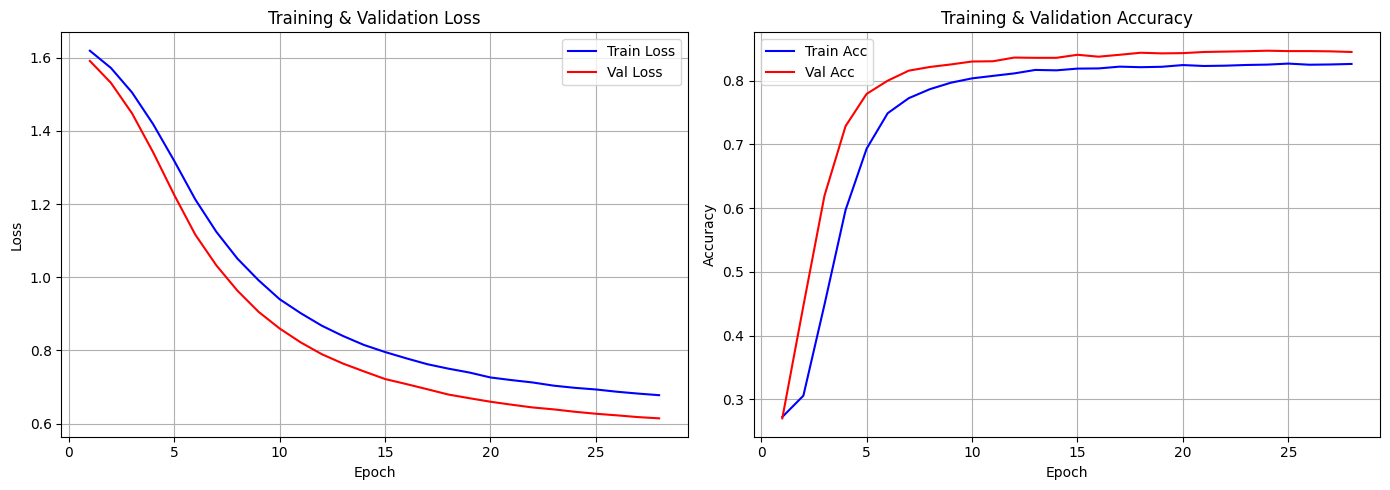

In [8]:
epochs = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs, train_losses, "b-", label="Train Loss")
ax1.plot(epochs, val_losses, "r-", label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True)
ax2.plot(epochs, train_accs, "b-", label="Train Acc")
ax2.plot(epochs, val_accs, "r-", label="Val Acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig("training_curves_optimized.png", dpi=150)
plt.show()

## Evaluation on Test Set

In [9]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(device, non_blocking=USE_AMP)
        attention_mask = batch["attention_mask"].to(device, non_blocking=USE_AMP)
        labels = batch["label"].to(device, non_blocking=USE_AMP)
        with autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
macro_precision = precision_score(
    all_labels, all_preds, average="macro", zero_division=0
)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
print("=" * 60)
print("TEST RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        all_labels, all_preds, target_names=list(LABEL2ID.keys()), zero_division=0
    )
)

Testing: 100%|██████████| 53/53 [00:02<00:00, 21.54it/s]

TEST RESULTS
Accuracy: 0.8434
Macro F1-Score: 0.7814
Macro Precision: 0.7835
Macro Recall: 0.7823

Classification Report:
              precision    recall  f1-score   support

  BACKGROUND       0.58      0.70      0.63       443
   OBJECTIVE       0.69      0.64      0.66       395
     METHODS       0.90      0.91      0.91      1662
     RESULTS       0.90      0.89      0.90      1725
 CONCLUSIONS       0.84      0.77      0.80       793

    accuracy                           0.84      5018
   macro avg       0.78      0.78      0.78      5018
weighted avg       0.85      0.84      0.84      5018



## Confusion Matrix & Per-Class Metrics

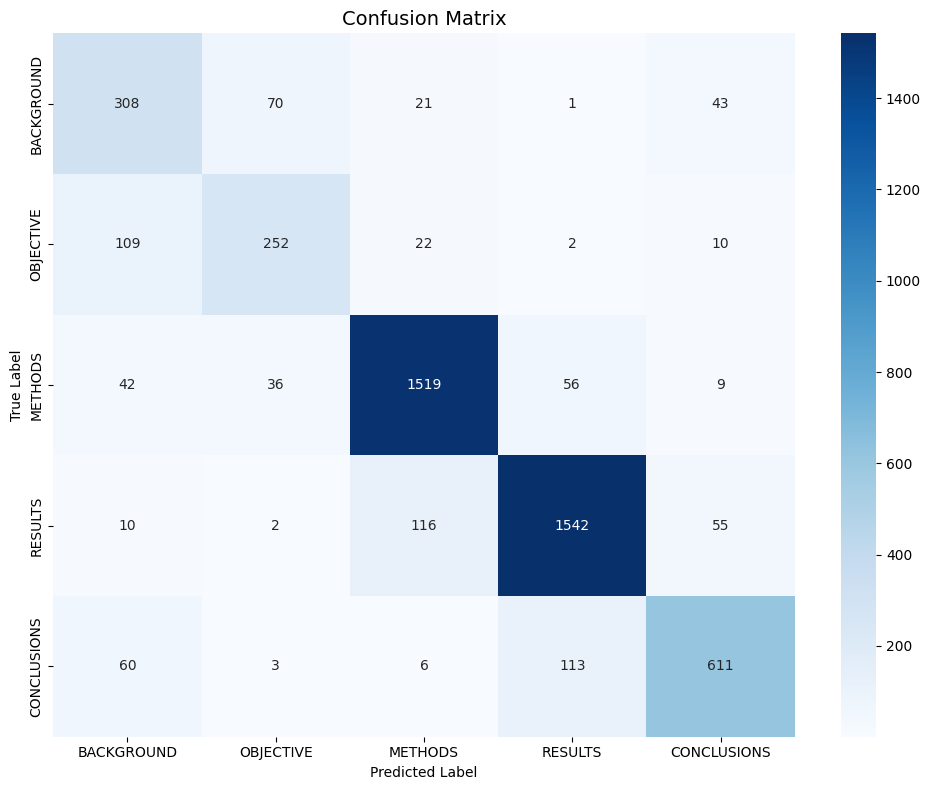

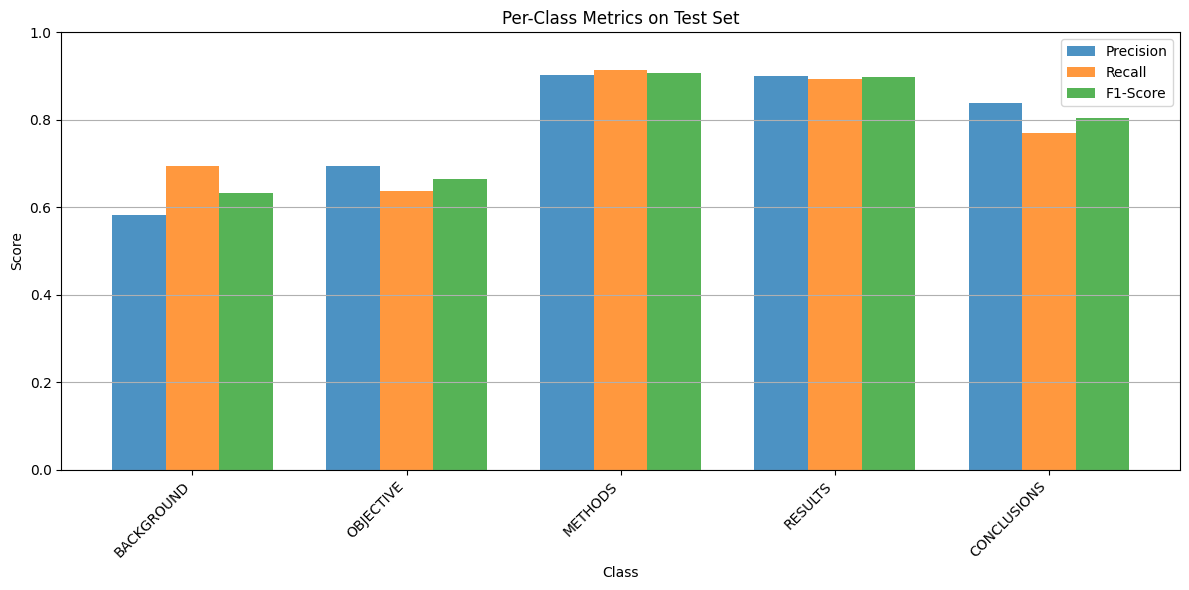

In [10]:
cm = confusion_matrix(all_labels, all_preds)
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
per_class_precision = precision_score(
    all_labels, all_preds, average=None, zero_division=0
)
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(LABEL2ID.keys()),
    yticklabels=list(LABEL2ID.keys()),
)
plt.title("Confusion Matrix", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_optimized.png", dpi=150)
plt.show()

classes = list(LABEL2ID.keys())
x = np.arange(len(classes))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, per_class_precision, width, label="Precision", alpha=0.8)
ax.bar(x, per_class_recall, width, label="Recall", alpha=0.8)
ax.bar(x + width, per_class_f1, width, label="F1-Score", alpha=0.8)
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics on Test Set")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("per_class_metrics_optimized.png", dpi=150)
plt.show()

## Save Artifacts

In [11]:
# Optional: copy artifacts to Drive if you are running in Colab
# from google.colab import drive
# drive.mount('/content/drive')
# !cp best_model_optimized.pth /content/drive/MyDrive/
# !cp *_optimized.png /content/drive/MyDrive/